In [2]:
!pip install transformers datasets scikit-learn gradio matplotlib seaborn -q

Using device: cuda


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT: {'accuracy': 0.8625, 'f1': 0.8600508905852418}
DistilBERT: {'accuracy': 0.825, 'f1': 0.8157894736842105}


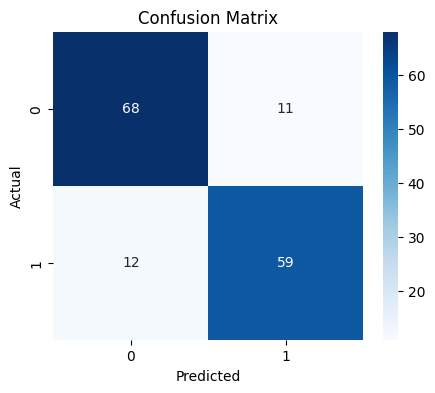

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9111d28494271cf402.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [3]:
# =========================
# IMPORTS
# =========================
import traceback

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# LOAD DATA (FAST SETTINGS)
# =========================
dataset = load_dataset("imdb")
dataset["train"] = dataset["train"].shuffle(seed=42).select(range(1000))
dataset["test"] = dataset["test"].shuffle(seed=42).select(range(400))

MAX_LEN = 128


def inputs_to_device(batch, dev):
    return {k: v.to(dev) for k, v in batch.items()}


# =========================
# TOKENIZE
# =========================
def tokenize_data(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize(example):
        return tokenizer(
            example["text"],
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
        )

    tokenized = dataset.map(tokenize, batched=True)
    if "label" in tokenized["train"].column_names:
        tokenized = tokenized.rename_column("label", "labels")

    tokenized.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"],
    )
    return tokenizer, tokenized


# =========================
# TRAIN (NO TRAINER)
# =========================
def train_model(model_name, epochs=1, batch_size=16):
    tokenizer, tokenized = tokenize_data(model_name)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        attn_implementation="eager",
    )
    model.to(device)

    train_loader = DataLoader(tokenized["train"], batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

    model.train()
    for _ in range(epochs):
        for batch in train_loader:
            batch = inputs_to_device(batch, device)
            outputs = model(**batch)
            loss = outputs.loss
            if loss is None:
                raise RuntimeError(
                    "loss is None — expected batch key 'labels'. Keys: " + str(list(batch.keys()))
                )
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

    model.eval()
    preds, labels = [], []
    for sample in tokenized["test"]:
        batch = {
            "input_ids": sample["input_ids"].unsqueeze(0).to(device),
            "attention_mask": sample["attention_mask"].unsqueeze(0).to(device),
        }
        with torch.no_grad():
            outputs = model(**batch)
        pred = torch.argmax(outputs.logits, dim=1).item()
        preds.append(pred)
        y = sample["labels"]
        labels.append(int(y.item()) if torch.is_tensor(y) else int(y))

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    return model, tokenizer, {"accuracy": acc, "f1": f1}, tokenized["test"]


# =========================
# TRAIN MODELS
# =========================
bert_model, bert_tokenizer, bert_results, test_data = train_model(
    "bert-base-uncased", epochs=1, batch_size=16
)
distil_model, distil_tokenizer, distil_results, _ = train_model(
    "distilbert-base-uncased", epochs=1, batch_size=16
)

print("BERT:", bert_results)
print("DistilBERT:", distil_results)


# =========================
# CONFUSION MATRIX
# =========================
def plot_confusion_matrix(model, tokenizer, dataset_split):
    model.eval()
    preds, labels = [], []
    for sample in dataset_split:
        inputs = tokenizer(
            sample["text"],
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
        )
        inputs = inputs_to_device(inputs, device)
        with torch.no_grad():
            outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()
        preds.append(pred)
        labels.append(int(sample["label"]))

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


plot_confusion_matrix(bert_model, bert_tokenizer, dataset["test"].select(range(150)))


# =========================
# EXPLAINABILITY
# =========================
def explain_prediction(text, model, tokenizer):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LEN)
    inputs = inputs_to_device(inputs, device)

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    if outputs.attentions is None:
        return [("attention_not_available", 0.0)]

    attentions = outputs.attentions[-1]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    attn = attentions[0].mean(dim=0)
    scores = attn.mean(dim=0).detach().cpu().numpy()

    m = min(len(tokens), len(scores))
    important_tokens = sorted(
        zip(tokens[:m], scores[:m]),
        key=lambda x: x[1],
        reverse=True,
    )[:10]
    return important_tokens


# =========================
# PREDICT
# =========================
def predict(text, model, tokenizer):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LEN)
    inputs = inputs_to_device(inputs, device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    confidence = probs.max().item()
    label = "Positive" if pred == 1 else "Negative"
    explanation = explain_prediction(text, model, tokenizer)
    return label, confidence, explanation


# =========================
# UI
# =========================
import gradio as gr


def app_fn(text, model_choice):
    try:
        if not text or not text.strip():
            return "Please enter text.", ""

        if model_choice == "BERT":
            model, tokenizer = bert_model, bert_tokenizer
        else:
            model, tokenizer = distil_model, distil_tokenizer

        label, confidence, explanation = predict(text.strip(), model, tokenizer)
        explanation_text = "\n".join(
            f"{tok}: {round(float(score), 3)}" for tok, score in explanation
        )
        return f"{label} ({round(confidence * 100, 2)}%)", explanation_text
    except Exception as e:
        return f"ERROR: {type(e).__name__}: {e}", traceback.format_exc()


iface = gr.Interface(
    fn=app_fn,
    inputs=[
        gr.Textbox(label="Enter Text"),
        gr.Radio(["BERT", "DistilBERT"], label="Choose Model", value="DistilBERT"),
    ],
    outputs=[
        gr.Text(label="Prediction"),
        gr.Textbox(label="Important Words"),
    ],
    title="Transformer Sentiment Analyzer (Fast Colab)",
)

iface.launch(share=True)